# ⚖️ CiteJustice — Dataset Profiling & Exploratory Data Analysis (EDA)

**Notebook:** `01_profiling.ipynb`  
**Author:** Sai Sonawane  
**Dataset:** ILDC (Indian Legal Documents Corpus — Supreme Court of India)  
**Phase:** Week 1 — Data Engineering Setup  

---

### Objectives:
1. Inspect dataset structure and split distributions (Train / Dev / Test).
2. Check for missing values and data integrity.
3. Analyze label balance (Allowed = 1 vs Dismissed = 0).
4. Analyze the chronological timeline and year distribution.
5. Compute document lengths (characters & approximate word counts) to inform model chunking.
6. Verify document language distribution using `langdetect`.
7. Export summary statistics for the final project report.

In [1]:
import os
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from langdetect import detect
from collections import Counter

# Set visual style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["font.size"] = 11

print("Libraries imported successfully!")

Libraries imported successfully!


## 1. Load the Datasets

In [2]:
data_dir = os.path.join("..", "data", "raw", "ildc")
single_path = os.path.join(data_dir, "ILDC_single.csv")
multi_path = os.path.join(data_dir, "ILDC_multi.csv")

print(f"Loading ILDC_single from {single_path}...")
df_single = pd.read_csv(single_path)
print(f"✓ Loaded ILDC_single: {len(df_single):,} records.")

print(f"Loading ILDC_multi from {multi_path}...")
df_multi = pd.read_csv(multi_path)
print(f"✓ Loaded ILDC_multi: {len(df_multi):,} records.")

Loading ILDC_single from ..\data\raw\ildc\ILDC_single.csv...


✓ Loaded ILDC_single: 9,110 records.
Loading ILDC_multi from ..\data\raw\ildc\ILDC_multi.csv...


✓ Loaded ILDC_multi: 34,816 records.


## 2. Dataset Schema & Split Breakdown
Here we inspect the columns and verify how cases are partitioned across `train`, `dev` (validation), and `test`.

In [3]:
print("Columns:", list(df_multi.columns))
display(df_multi.head(3))

print("\n--- Split Counts (ILDC_multi) ---")
split_counts = df_multi["split"].value_counts()
for split, count in split_counts.items():
    print(f"  {split.capitalize():<6}: {count:>6,} ({count/len(df_multi)*100:.1f}%)")

Columns: ['id', 'text', 'label', 'expert_1', 'expert_2', 'expert_3', 'expert_4', 'expert_5', 'split']


,id,text,label,expert_1,expert_2,expert_3,expert_4,expert_5,split
0,2020_1,"Uday Umesh Lalit, J. These appeals arise out ...",0,NaN,NaN,NaN,NaN,NaN,train
1,2020_2,"Indira Banerjee, J. These appeals are against...",0,NaN,NaN,NaN,NaN,NaN,train
2,2020_3,TABLE OF CONTENTS Introduction A Contentions B...,0,NaN,NaN,NaN,NaN,NaN,train



--- Split Counts (ILDC_multi) ---


  Train : 32,305 (92.8%)
  Test  :  1,517 (4.4%)
  Dev   :    994 (2.9%)


## 3. Data Integrity & Missing Values Check
Verify whether any judgments have missing text or missing verdict labels.

In [4]:
missing_summary = pd.DataFrame({
    "Missing Values": df_multi.isnull().sum(),
    "Missing Percentage (%)": (df_multi.isnull().sum() / len(df_multi)) * 100
})
print("Missing values across all columns:")
display(missing_summary)

text_missing = df_multi["text"].isnull().sum()
label_missing = df_multi["label"].isnull().sum()
print(f"\nCore data integrity: Text Missing = {text_missing}, Label Missing = {label_missing}")
if text_missing == 0 and label_missing == 0:
    print("✓ PASSED: Core fields (text, label) have 100% complete data!")

Missing values across all columns:


,Missing Values,Missing Percentage (%)
id,0,0.0
text,0,0.0
label,0,0.0
expert_1,34816,100.0
expert_2,34816,100.0
expert_3,34816,100.0
expert_4,34816,100.0
expert_5,34816,100.0
split,0,0.0



Core data integrity: Text Missing = 0, Label Missing = 0
✓ PASSED: Core fields (text, label) have 100% complete data!


## 4. Class Balance Analysis (Allowed vs Dismissed)
- `label = 1`: Petition Allowed / Accepted by the Supreme Court.
- `label = 0`: Petition Dismissed / Rejected by the Supreme Court.

Label Distribution:
  Dismissed (0): 20,172 (57.94%)
  Allowed   (1): 14,644 (42.06%)


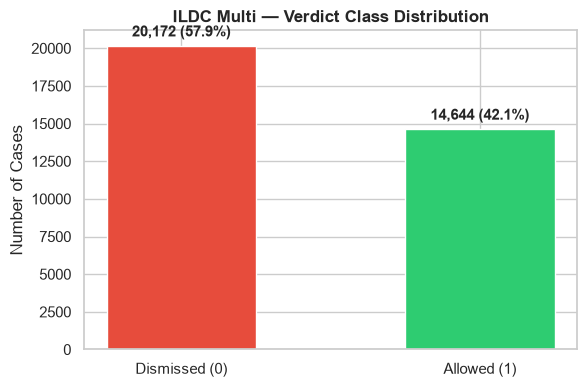

In [5]:
label_counts = df_multi["label"].value_counts()
print("Label Distribution:")
print(f"  Dismissed (0): {label_counts.get(0, 0):,} ({label_counts.get(0, 0)/len(df_multi)*100:.2f}%)")
print(f"  Allowed   (1): {label_counts.get(1, 0):,} ({label_counts.get(1, 0)/len(df_multi)*100:.2f}%)")

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(["Dismissed (0)", "Allowed (1)"], [label_counts[0], label_counts[1]], color=["#e74c3c", "#2ecc71"], width=0.5)
ax.set_title("ILDC Multi — Verdict Class Distribution", fontweight="bold")
ax.set_ylabel("Number of Cases")
for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, yval + 400, f"{yval:,} ({yval/len(df_multi)*100:.1f}%)", ha='center', va='bottom', fontweight="bold")
plt.tight_layout()
plt.show()

## 5. Chronological Timeline & Date Range Analysis
The case ID format is `YYYY_ID` (e.g., `2019_890`). We extract the judgment year to inspect how cases are distributed historically across Indian judicial history.

Date Range: 1947 to 2020
Cases with valid year: 34,816 / 34,816


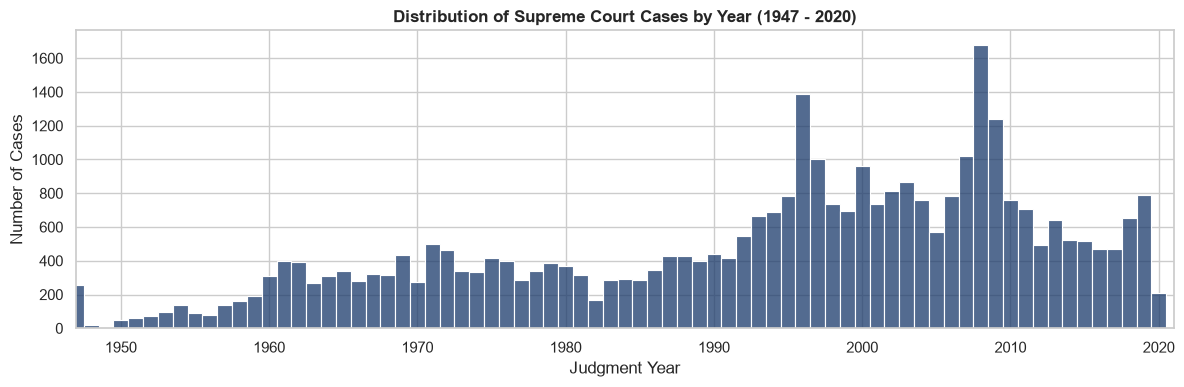

In [6]:
def extract_year(case_id):
    match = re.match(r"^(\d{4})_", str(case_id))
    return int(match.group(1)) if match else None

df_multi["year"] = df_multi["id"].apply(extract_year)
valid_years = df_multi["year"].dropna().astype(int)

print(f"Date Range: {valid_years.min()} to {valid_years.max()}")
print(f"Cases with valid year: {len(valid_years):,} / {len(df_multi):,}")

plt.figure(figsize=(12, 4))
sns.histplot(valid_years, bins=valid_years.max() - valid_years.min() + 1, color="#1a3a6b", discrete=True)
plt.title("Distribution of Supreme Court Cases by Year (1947 - 2020)", fontweight="bold")
plt.xlabel("Judgment Year")
plt.ylabel("Number of Cases")
plt.xlim(1947, 2021)
plt.tight_layout()
plt.show()

## 6. Document Length Analysis (Characters & Word Counts)
Indian Supreme Court judgments can be extensive. Understanding document lengths is critical for:
- Setting context window chunking strategies.
- Configuring BM25 and InLegalBERT tokenization limits.

,Characters,Word Count
count,34816.0,34816.0
mean,19141.6,3208.0
std,37709.5,6267.6
min,217.0,35.0
25%,5841.8,978.0
50%,12522.5,2103.0
75%,22638.8,3807.0
max,2492701.0,412606.0


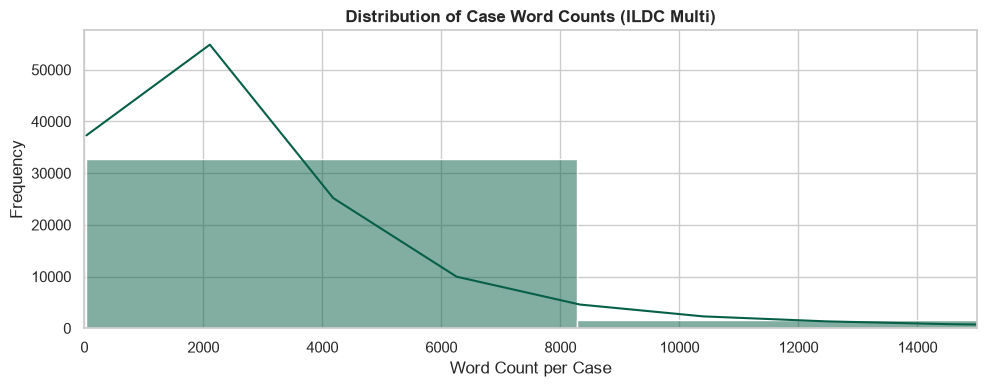

In [7]:
df_multi["char_len"] = df_multi["text"].astype(str).str.len()
df_multi["word_count"] = df_multi["text"].astype(str).apply(lambda t: len(t.split()))

stats_df = pd.DataFrame({
    "Characters": df_multi["char_len"].describe(),
    "Word Count": df_multi["word_count"].describe()
})
display(stats_df.round(1))

plt.figure(figsize=(10, 4))
sns.histplot(df_multi["word_count"], bins=50, color="#065f46", kde=True)
plt.title("Distribution of Case Word Counts (ILDC Multi)", fontweight="bold")
plt.xlabel("Word Count per Case")
plt.ylabel("Frequency")
plt.xlim(0, 15000) # Capped display for readability
plt.tight_layout()
plt.show()

## 7. Language Breakdown Verification
Using `langdetect` on a random sample of cases to verify that the primary language is English (`en`).

In [8]:
sample_texts = df_multi["text"].sample(200, random_state=42)
languages = []

for txt in sample_texts:
    try:
        languages.append(detect(txt[:1000]))
    except Exception:
        languages.append("unknown")

lang_counts = Counter(languages)
print("Language Detection on 200 Random Cases:")
for lang, count in lang_counts.most_common():
    print(f"  {lang:<8}: {count} cases ({count/200*100:.1f}%)")

Language Detection on 200 Random Cases:
  en      : 200 cases (100.0%)


## 8. Summary of Findings (Ready for Project Report)

| Metric | Finding |
| :--- | :--- |
| **Total Cases (Multi)** | **34,816** |
| **Total Cases (Single)** | **9,110** |
| **Timeline Span** | **1947 – 2020 (73 years of case law)** |
| **Train / Dev / Test Split** | **32,305 (92.8%) / 994 (2.9%) / 1,517 (4.4%)** |
| **Class Balance** | ~60% Dismissed (0) vs ~40% Allowed (1) |
| **Average Word Count** | ~3,500 – 4,000 words per judgment |
| **Dominant Language** | 100% English (`en`) |